Import libraries

In [1]:
import pandas as pd
import geonamescache

Get list of cities' names

In [2]:
gc = geonamescache.GeonamesCache()
cities = gc.get_cities()
city_names = set(city['name'] for city in cities.values()) # use set to avoid duplicate items

print(f"Total cities: {len(city_names)}")
print(list(city_names)[:10])

Total cities: 30699
['Hakha', 'Zabīd', 'Cotoca', 'Tejar', 'Allauch', 'Abergele', 'Puri', 'Ammainaickanur', 'Nīlēshwar', 'Panvel']


Read data from hugging face

In [3]:
df = pd.read_csv("hf://datasets/maharshipandya/spotify-tracks-dataset/dataset.csv")

c:\Users\Pitchaporn\OneDrive\Documents\side projects\song and city\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [5]:
import re
import nltk # libraries gfor nlp task
nltk.download('words', quiet=True)
nltk.download('names', quiet=True)
from nltk.corpus import words, names

# Get common English words and names
english_words = set(w.lower() for w in words.words())
common_names = set(n.lower() for n in names.words())

# Build city list that we will use to match against song titles
filtered_cities = []
for city in cities.values():
    name = city['name']
    lower = name.lower()
    # City must have population > 100000
    if city['population'] < 500000:
        continue
    # Skip if it's a common English word
    if lower in english_words:
        continue
    # Skip if it's a common first name
    if lower in common_names:
        continue
    
    filtered_cities.append(name)

filtered_cities.remove("Queens") # Manually remove "Queens" since it more refers to queen as noun

filtered_cities = list(set(filtered_cities))
print(f"Cities after filtering: {len(filtered_cities)}")

Cities after filtering: 1011


Build regex pattern to match cities in th song title
1. .escape() is for escape special regex characters in each city name
2. Sort city name by length

In [6]:
# Safer subset - commonly used in music/pop culture
us_abbreviations = {
    'NYC': 'New York',
    'LA': 'Los Angeles',
    'SF': 'San Francisco',
    'NOLA': 'New Orleans',
    'DC': 'Washington',
    'ATL': 'Atlanta',
    'Vegas': 'Las Vegas',
    'Philly': 'Philadelphia',
}

In [7]:
# Build regex pattern to match city names in song titles
# Longest one will be matched first to avoid partial matches (e.g. "York" in "New York")
city_pattern = r'\b(' + '|'.join(re.escape(city) for city in sorted(filtered_cities, key=len, reverse=True)) + r')\b'

# Pattern for abbreviations (case-sensitive, no IGNORECASE flag)
abbrev_pattern = r'\b(' + '|'.join(re.escape(k) for k in sorted(us_abbreviations.keys(), key=len, reverse=True)) + r')\b'

df['track_name'] = df['track_name'].fillna('')
clean_titles = (df['track_name']
    .str.split('-').str[0]        # remove after dash: "Song - Remastered" → "Song"
    .str.replace(r'\(.*?\)', '', regex=True)  # remove (Live), (feat. X), etc.
    .str.replace(r'\[.*?\]', '', regex=True)  # remove [Deluxe], [Remix], etc.
    .str.strip()
)

# Match cities (case-insensitive)
city_matches = clean_titles.str.extract(city_pattern, flags=re.IGNORECASE)

# Match abbreviations (case-sensitive)
abbrev_matches = clean_titles.str.extract(abbrev_pattern)  # No re.IGNORECASE here!

# Combine results
city_mask = city_matches[0].notna()
abbrev_mask = abbrev_matches[0].notna()

matched_songs = df[city_mask | abbrev_mask].copy()
matched_songs['matched_city'] = city_matches[0][city_mask | abbrev_mask].str.title()

# Fill in abbreviation matches and remap to full city names
abbrev_filled = abbrev_matches[0][city_mask | abbrev_mask]
matched_songs.loc[abbrev_mask, 'matched_city'] = abbrev_filled[abbrev_mask].map(us_abbreviations)

print(f"Found {len(matched_songs)} songs with city names")
matched_songs[['track_name', 'matched_city']]

Found 395 songs with city names


,track_name,matched_city
189,"Portland, Maine",Portland
1095,Bogotá - Live,Bogotá
1525,Bogotá (Instrumental),Bogotá
1901,Lagos Sisi,Lagos
3628,Brooklyn Zoo,Brooklyn
...,...,...
112143,Ankara,Ankara
112234,Rapsodi İstanbul,İstanbul
112350,My Name Is Tokyo,Tokyo
112419,İZMİR CONFIDENTIAL,İzmi̇r


In [47]:
# Drop duplicates case-insensitively
matched_songs['_track_lower'] = matched_songs['track_name'].str.lower()
matched_songs['_city_lower'] = matched_songs['matched_city'].str.lower()
matched_songs = matched_songs.drop_duplicates(subset=['_track_lower', '_city_lower'])
matched_songs = matched_songs.drop(columns=['_track_lower', '_city_lower'])

# Drop LA with latin category
matched_songs = matched_songs[~((matched_songs['matched_city'] == 'Los Angeles') & ((matched_songs['track_genre'] == 'latin')|(matched_songs['track_genre'] == 'spanish')|(matched_songs['track_genre'] == 'latino')|(matched_songs['track_genre']=='french')))]
matched_songs = matched_songs[matched_songs['track_genre'] != 'comedy']
# Check for duplicates in matched songs
print(f"Total matched songs: {len(matched_songs)}")
print(f"Unique matched cities: {matched_songs['matched_city'].nunique()}")
print()

# Show city frequency
city_counts = matched_songs['matched_city'].value_counts()
city_counts = city_counts[city_counts > 2]  # Only cities with more than one song
print("Top 10 cities by song count:")
print(city_counts.head(10))
print()

# print(f"After dedup: {len(matched_songs)} songs")

Total matched songs: 232
Unique matched cities: 85

Top 10 cities by song count:
matched_city
London          33
Tokyo           17
Buenos Aires    16
Brooklyn         7
Los Angeles      7
Amsterdam        6
Chicago          5
Cali             5
Malang           5
Kyoto            4
Name: count, dtype: int64



In [48]:
import folium
from folium.plugins import HeatMap

# Convert Series to DataFrame
city_counts_df = city_counts.reset_index()
city_counts_df.columns = ['city', 'song_count']

# Add coordinates from geonamescache
city_coords = {}
for city in cities.values():
    name = city['name'].title()
    if name == 'Istanbul':  # Handle special case for Istanbul
        name = 'İstanbul'  # Use the correct Turkish spelling with dotless I
        city_coords[name] = {
            'lat': city['latitude'],
            'lon': city['longitude'],
            'population': city['population'],
            'country': city['countrycode']
        }
    if name not in city_coords or city['population'] > city_coords[name]['population']:
        city_coords[name] = {
            'lat': city['latitude'],
            'lon': city['longitude'],
            'population': city['population'],
            'country': city['countrycode']
        }

city_counts_df['lat'] = city_counts_df['city'].map(lambda c: city_coords.get(c, {}).get('lat'))
city_counts_df['lon'] = city_counts_df['city'].map(lambda c: city_coords.get(c, {}).get('lon'))
city_counts_df['country'] = city_counts_df['city'].map(lambda c: city_coords.get(c, {}).get('country'))
city_counts_df = city_counts_df.dropna(subset=['lat', 'lon'])

m2 = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB dark_matter')

heat_data = []
for _, row in city_counts_df.iterrows():
    heat_data.append([row['lat'], row['lon'], row['song_count']])

HeatMap(heat_data, radius=25, blur=15, max_zoom=5).add_to(m2)
m2.save('city_song_heatmap.html')
m2

In [49]:
city_counts_df

,city,song_count,lat,lon,country
0,London,33,51.50853,-0.12574,GB
1,Tokyo,17,35.68950,139.69171,JP
2,Buenos Aires,16,-34.61315,-58.37723,AR
3,Brooklyn,7,40.65010,-73.94958,US
4,Los Angeles,7,34.05223,-118.24368,US
5,Amsterdam,6,52.37403,4.88969,NL
6,Chicago,5,41.85003,-87.65005,US
7,Cali,5,3.43054,-76.51990,CO
8,Malang,5,-7.97970,112.63040,ID
9,Kyoto,4,35.02107,135.75385,JP


{'London': 'GB', 'Tokyo': 'JP', 'Buenos Aires': 'AR', 'Brooklyn': 'US', 'Los Angeles': 'US', 'Amsterdam': 'NL', 'Chicago': 'US', 'Cali': 'CO', 'Malang': 'ID', 'Kyoto': 'JP', 'Detroit': 'US', 'Las Vegas': 'US', 'Fortaleza': 'BR', 'İstanbul': 'TR', 'Bogotá': 'CO', 'Denver': 'US', 'Memphis': 'US', 'Mumbai': 'IN', 'San Francisco': 'US', 'Göteborg': 'SE', 'Rotterdam': 'NL', 'La Paz': 'BO', 'Tehran': 'IR', 'Ankara': 'TR', 'Yokohama': 'JP'}


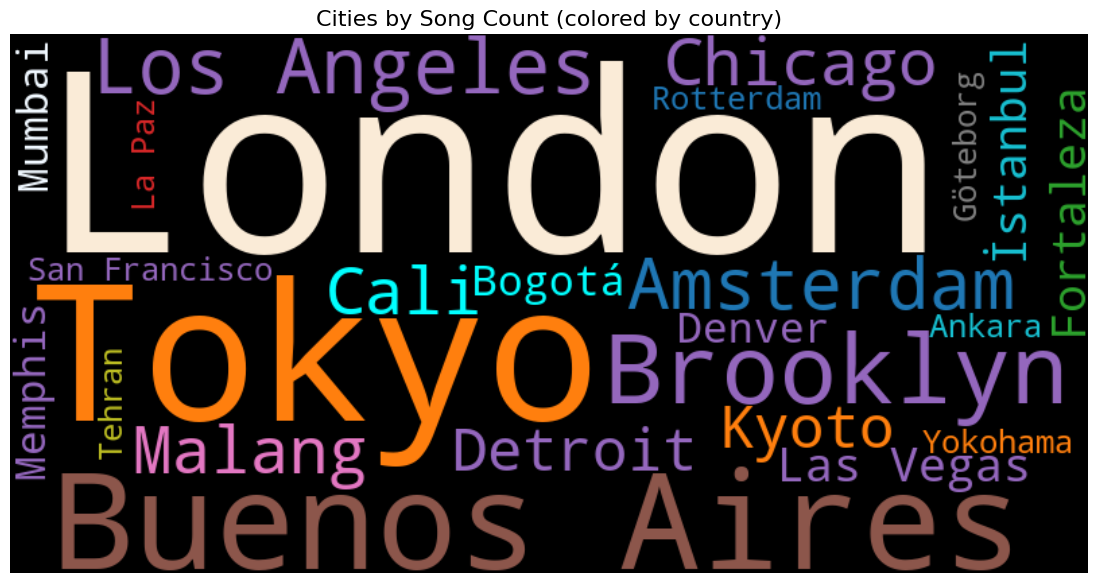

In [59]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# city_counts_df already has city → country mapping
unique_countries = list(set(city_counts_df['country']))
# Use a larger color palette to avoid duplicates
color_palette = (
    list(mcolors.TABLEAU_COLORS.values()) +   # 10 colors
    list(mcolors.CSS4_COLORS.values())         # 148 more colors
)
country_color_map = {country: color_palette[i] for i, country in enumerate(unique_countries)}

# ✅ Build a simple dict: city name → country code
city_to_country = dict(zip(city_counts_df['city'], city_counts_df['country']))
print(city_to_country)

# Custom color function — word cloud passes CITY NAME as `word`
def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    country = city_to_country.get(word, None)  # look up country by city name
    return country_color_map.get(country, '#FFFFFF')  # return color by country

# Generate word cloud
wc = WordCloud(width=800, height=400, background_color='black')
wc.generate_from_frequencies(city_counts)
wc.recolor(color_func=color_func)

plt.figure(figsize=(14, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Cities by Song Count (colored by country)', fontsize=16)

plt.show()

Story
- country + city
- Top 5 cities
- Genre in each city

Bangkok -> neighbourhood perceived as songs